In [27]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf 
from tensorflow.keras.layers import TextVectorization 
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [28]:
dataset = pd.read_csv("/kaggle/input/datasets/tobiasbueck/multilingual-customer-support-tickets/aa_dataset-tickets-multi-lang-5-2-50-version.csv")
dataset_en = dataset[dataset['language'] == 'en'].copy()


In [29]:
dataset_en

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN
5,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28578,Problem with Billing Adjustment,An unexpected billing discrepancy has been not...,We apologize for the billing discrepancy in th...,Incident,Billing and Payments,high,en,400,Billing,Payment,Performance,Bug,NaN,NaN,NaN,NaN
28580,Urgent: Incident Involving Data Breach in Medi...,"A data breach has occurred, which might be rel...","Dear [Name], we acknowledge the urgency of the...",Problem,Product Support,medium,en,400,Security,Incident,Bug,Performance,NaN,NaN,NaN,NaN
28582,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,We are addressing the performance issue with t...,Incident,Technical Support,high,en,400,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,NaN
28585,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Received your request for updates on the integ...,Change,IT Support,high,en,400,Feature,IT,Tech Support,NaN,NaN,NaN,NaN,NaN


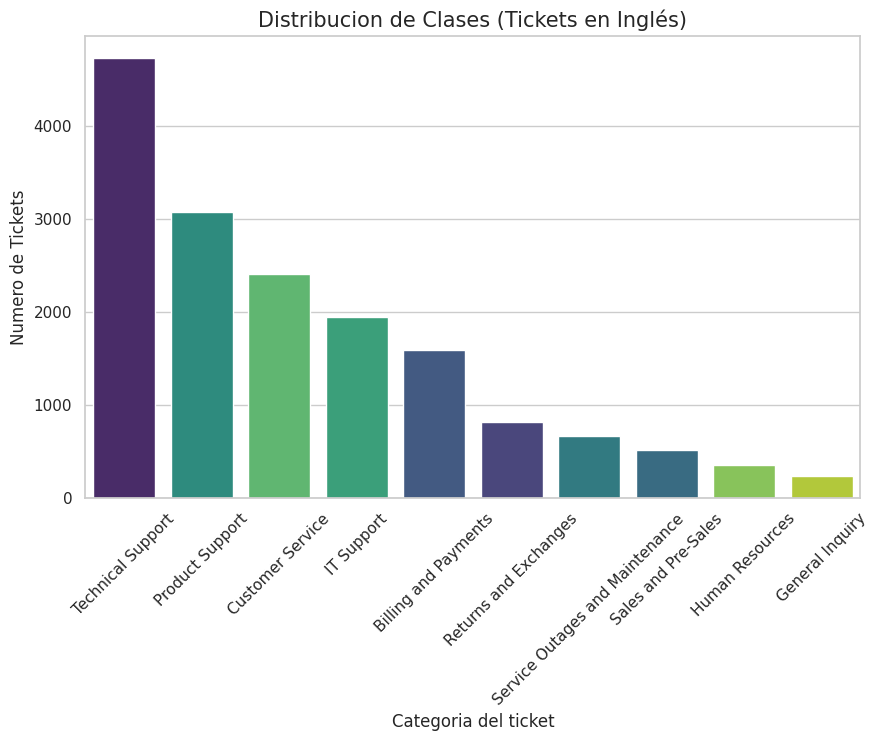

In [30]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
ax = sns.countplot(data=dataset_en, x='queue', palette='viridis', hue ='queue', legend=False, order=dataset_en['queue'].value_counts().index)
plt.title('Distribucion de Clases (Tickets en Inglés)',fontsize=15)
plt.xlabel('Categoria del ticket', fontsize=12)
plt.ylabel('Numero de Tickets', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [31]:
lengths = [len(text.split()) for text in dataset_en['body']]
print(f"Mediana:{np.median(lengths):.1f}")

Mediana:55.0


In [32]:
from collections import Counter

# Tokenizar manualmente para analizar
def simple_tokenize(texts):
    tokens = []
    for text in texts:
        text = text.lower()
        text = ''.join(c if c.isalnum() or c.isspace() else ' ' for c in text)
        tokens.extend(text.split())
    return tokens

all_tokens = simple_tokenize(dataset_en['body'])
vocab_counter = Counter(all_tokens)

print(f"Vocabulario total único: {len(vocab_counter)}")

Vocabulario total único: 5054


In [33]:
output_sequence_length = int(np.median(lengths))
max_tokens = len(vocab_counter)


In [34]:
vectorize_layer = TextVectorization( 
max_tokens=max_tokens, 
output_mode='int', # Genera secuencias de enteros 
output_sequence_length=output_sequence_length, 
standardize='lower_and_strip_punctuation' 
)

In [35]:
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(dataset_en[['queue']])

column_names = encoder.get_feature_names_out(['queue'])
one_hot_df = pd.DataFrame(encoded_array, columns=column_names, index=dataset_en.index)

df_encoded = pd.concat([dataset_en, one_hot_df], axis=1)

df_encoded = df_encoded.drop('queue', axis=1)
print(f"Encoded Employee data : \n{df_encoded}")

Encoded Employee data : 
                                                 subject  \
1                                     Account Disruption   
2      Query About Smart Home System Integration Feat...   
3                      Inquiry Regarding Invoice Details   
4      Question About Marketing Agency Software Compa...   
5                                          Feature Query   
...                                                  ...   
28578                    Problem with Billing Adjustment   
28580  Urgent: Incident Involving Data Breach in Medi...   
28582       Performance Problem with Data Analytics Tool   
28585  Update Request for SaaS Platform Integration F...   
28586          Inquiry About Project Management Features   

                                                    body  \
1      Dear Customer Support Team,\n\nI am writing to...   
2      Dear Customer Support Team,\n\nI hope this mes...   
3      Dear Customer Support Team,\n\nI hope this mes...   
4      Dear Su

In [36]:
from sklearn.model_selection import train_test_split

X = dataset_en['body'] 

y = one_hot_df 

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,    
    random_state=42,   
    stratify=dataset_en['queue'] )


# Transformer

In [37]:
from keras.layers import Dense, Dropout, Bidirectional, Embedding 
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
early_stop = EarlyStopping(
    monitor='val_loss',      # Vigila la pérdida en el set de validación
    patience=5,              # Si después de 3 épocas no mejora, se detiene
    restore_best_weights=True, # Muy importante: recupera los mejores pesos, no los últimos
    verbose = 1
)

In [39]:
vectorize_layer.adapt(X_train) 
vocab = vectorize_layer.get_vocabulary() 
print(f"Vocabulario: {vocab[:5]}")

embedding_layer = Embedding(input_dim=len(vocab), output_dim=50, mask_zero=True)
entrada = np.array([[4, 3, 1, 1, 3]]) 
N = 20000 
T = 100 
D = 128             
# Dimensiones de los vectores de embedding 
EPOCHS = 10 
NEURONAS = 128

X_train = np.array(X_train.astype(str))
X_test = np.array(X_test.astype(str))

y_train = y_train.values.astype('float32')
y_test = y_test.values.astype('float32')

num_clases = y_train.shape[1]

embed_dim = 64  # Dimensión
num_heads = 2   # Número de cabezales de atención
ff_dim = 64     # Tamaño de la capa densa dentro del transformer

Vocabulario: ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('and')]


In [40]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"), 
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

inputs = layers.Input(shape=(), dtype=tf.string)
x = vectorize_layer(inputs)
x = TokenAndPositionEmbedding(275, max_tokens, 64)(x)
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
x = layers.GlobalAveragePooling1D()(x) # Colapsa la secuencia a un vector
x = layers.Dropout(0.1)(x)
x = layers.Dense(20, activation="relu")(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(20, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando Transformer...")
history = model.fit(
    X_train,y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks = [early_stop],
    verbose=1)


Entrenando Transformer...
Epoch 1/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.2772 - loss: 2.0356 - val_accuracy: 0.3443 - val_loss: 1.7586
Epoch 2/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3471 - loss: 1.7332 - val_accuracy: 0.3925 - val_loss: 1.6516
Epoch 3/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4139 - loss: 1.5711 - val_accuracy: 0.4063 - val_loss: 1.5931
Epoch 4/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4692 - loss: 1.4367 - val_accuracy: 0.4315 - val_loss: 1.5984
Epoch 5/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5134 - loss: 1.3271 - val_accuracy: 0.4331 - val_loss: 1.6105
Epoch 6/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5786 - loss: 1.1912 - val_accuracy: 0.4399 - val_loss: 1.6195
Epoch 7/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6002 - loss: 1.1020 - val_accuracy: 0.4583 - val_loss: 1.6658
Epoch 8/20
368/368 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6382

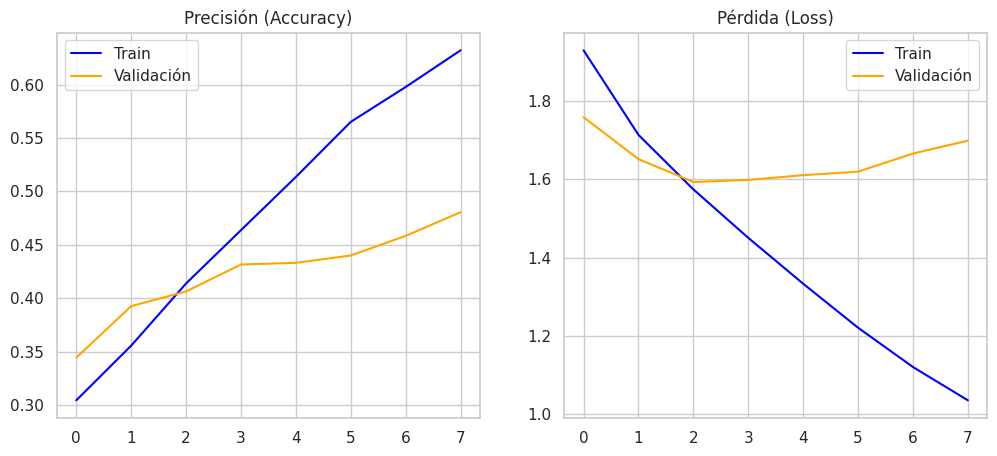

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


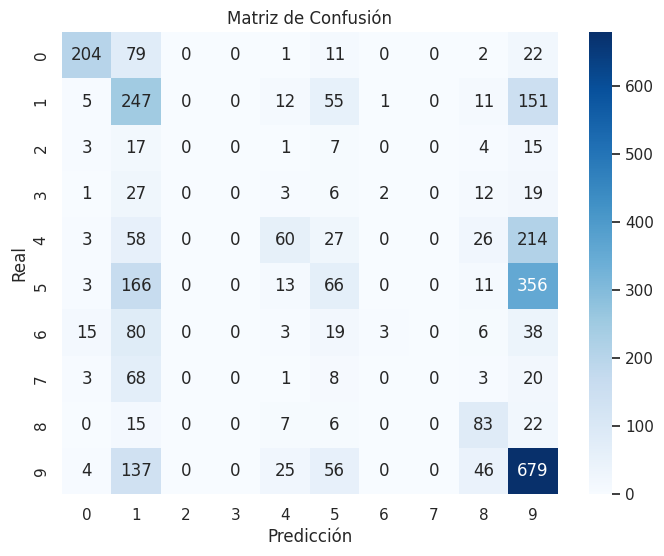

              precision    recall  f1-score   support

           0       0.85      0.64      0.73       319
           1       0.28      0.51      0.36       482
           2       0.00      0.00      0.00        47
           3       0.00      0.00      0.00        70
           4       0.48      0.15      0.23       388
           5       0.25      0.11      0.15       615
           6       0.50      0.02      0.04       164
           7       0.00      0.00      0.00       103
           8       0.41      0.62      0.49       133
           9       0.44      0.72      0.55       947

    accuracy                           0.41      3268
   macro avg       0.32      0.28      0.25      3268
weighted avg       0.40      0.41      0.36      3268

 pred[9 9 9 ... 0 4 9]
Hola [[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
def matrizConfusion(model, X_test, y_test, history):
    # 1. Gráficas de Loss y Accuracy (del historial)
    plt.figure(figsize=(12, 5))

    # Gráfica de Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validación', color='orange')
    plt.title('Precisión (Accuracy)')
    plt.legend()

    # Gráfica de Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train', color='blue')
    plt.plot(history.history['val_loss'], label='Validación', color='orange')
    plt.title('Pérdida (Loss)')
    plt.legend()
    
    plt.show()


    # 2. Predecir
    y_true = np.argmax(np.array(y_test), axis=1) # De One-Hot a números (0, 1, 2...)
    preds = model.predict(X_test)
    y_pred = np.argmax(preds, axis=1)

    # Mapa de calor
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    
    # 5. Reporte
    print(classification_report(y_true, y_pred))
    print(f" pred{y_true}")
    print(f"Hola {y_test}")
   

# Llamada simple
matrizConfusion(model, X_test, y_test, history)

# Roberta

In [42]:
import keras
import keras_hub

In [43]:
# Pretrained classifier.
modelo = keras_hub.models.RobertaClassifier.from_preset(
    "roberta_base_en",
    num_classes=num_clases,
    
)
modelo.backbone.trainable = False
optimizer = keras.optimizers.Adam(learning_rate=2e-5)

modelo.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),#From logits se pone porque en los modelos que ahi que rentrenar de este estilo no los ponen automaticamente
    metrics=["accuracy"]
)


modelo.summary()



Preprocessor: "roberta_text_classifier_preprocessor_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ roberta_tokenizer (RobertaTokenizer)                          │                       Vocab size: 50,265 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "roberta_text_classifier_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ roberta_backbone              │ (None, None, 768)         │     124,052,736 │ padding_mask[0][0],        │
│ (RobertaBackbone)             │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 768)               │               0 │ roberta_backbone[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dropout (Dropout)      │ (None, 768)               │               0 │ get_item_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ pooled_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 10)                │           7,690 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 124,651,018 (475.51 MB)

 Trainable params: 598,282 (2.28 MB)

 Non-trainable params: 124,052,736 (473.22 MB)

In [44]:
 history = modelo.fit(
    x=X_train, 
    y=y_train, 
    epochs = 2,
    validation_split=0.1,
    batch_size=4  # Prueba con 4 u 8 si 32 falla
)

Epoch 1/2
2941/2941 ━━━━━━━━━━━━━━━━━━━━ 525s 167ms/step - accuracy: 0.2767 - loss: 2.0258 - val_accuracy: 0.2846 - val_loss: 1.9504
Epoch 2/2
2941/2941 ━━━━━━━━━━━━━━━━━━━━ 465s 158ms/step - accuracy: 0.2903 - loss: 1.9488 - val_accuracy: 0.2846 - val_loss: 1.9342


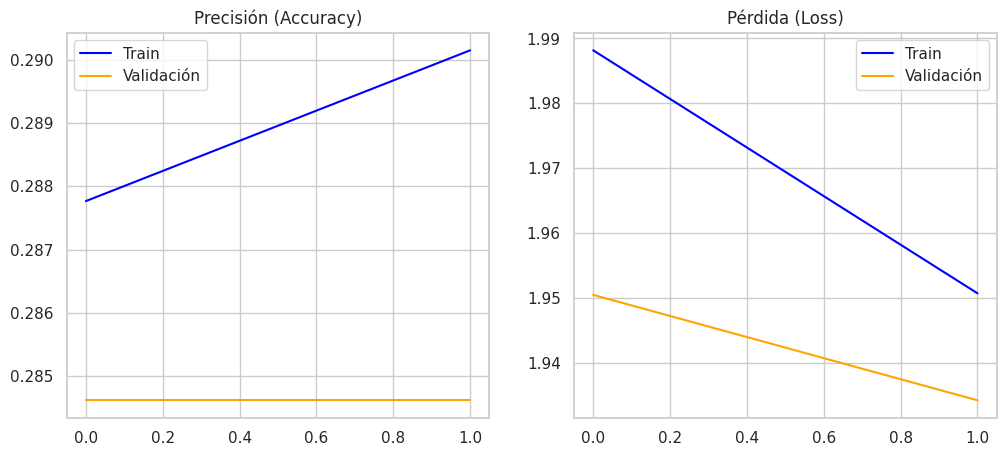

103/103 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step


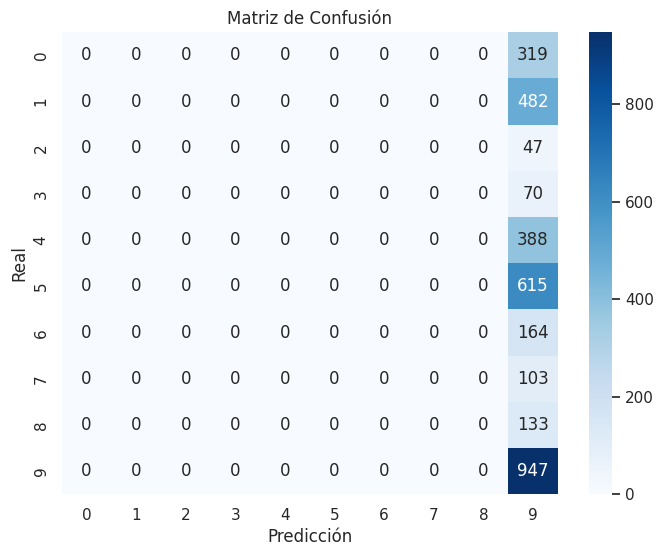

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       319
           1       0.00      0.00      0.00       482
           2       0.00      0.00      0.00        47
           3       0.00      0.00      0.00        70
           4       0.00      0.00      0.00       388
           5       0.00      0.00      0.00       615
           6       0.00      0.00      0.00       164
           7       0.00      0.00      0.00       103
           8       0.00      0.00      0.00       133
           9       0.29      1.00      0.45       947

    accuracy                           0.29      3268
   macro avg       0.03      0.10      0.04      3268
weighted avg       0.08      0.29      0.13      3268

 pred[9 9 9 ... 0 4 9]
Hola [[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:

matrizConfusion(modelo, X_test, y_test, history)

# Albert

In [55]:
# Pretrained classifier.
modelo = keras_hub.models.AlbertClassifier.from_preset(
    "albert_base_en_uncased",
    num_classes=num_clases,
    
)
modelo.backbone.trainable = False
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

modelo.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),#From logits se pone porque en los modelos que ahi que rentrenar de este estilo no los ponen automaticamente
    metrics=["accuracy"]
)


modelo.summary()

Preprocessor: "albert_text_classifier_preprocessor_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ albert_tokenizer (AlbertTokenizer)                            │                       Vocab size: 30,000 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "albert_text_classifier_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ segment_ids (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ albert_backbone               │ [(None, 768), (None,      │      11,683,584 │ padding_mask[0][0],        │
│ (AlbertBackbone)              │ None, 768)]               │                 │ segment_ids[0][0],         │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ albert_backbone[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 10)                │           7,690 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 11,691,274 (44.60 MB)

 Trainable params: 7,690 (30.04 KB)

 Non-trainable params: 11,683,584 (44.57 MB)

In [61]:
 history = modelo.fit(
    x=X_train, 
    y=y_train, 
    epochs = 5,
    validation_split=0.1,
    batch_size=4  # Prueba con 4 u 8 si 32 falla
)

Epoch 1/5
2941/2941 ━━━━━━━━━━━━━━━━━━━━ 451s 153ms/step - accuracy: 0.2610 - loss: 2.0549 - val_accuracy: 0.2892 - val_loss: 2.0540
Epoch 2/5
2941/2941 ━━━━━━━━━━━━━━━━━━━━ 440s 150ms/step - accuracy: 0.2669 - loss: 2.0351 - val_accuracy: 0.2907 - val_loss: 2.0669
Epoch 3/5
2941/2941 ━━━━━━━━━━━━━━━━━━━━ 439s 149ms/step - accuracy: 0.2719 - loss: 2.0280 - val_accuracy: 0.2915 - val_loss: 2.0369
Epoch 4/5
2941/2941 ━━━━━━━━━━━━━━━━━━━━ 439s 149ms/step - accuracy: 0.2701 - loss: 2.0208 - val_accuracy: 0.2953 - val_loss: 2.0813
Epoch 5/5
2941/2941 ━━━━━━━━━━━━━━━━━━━━ 438s 149ms/step - accuracy: 0.2697 - loss: 2.0220 - val_accuracy: 0.2961 - val_loss: 2.0924


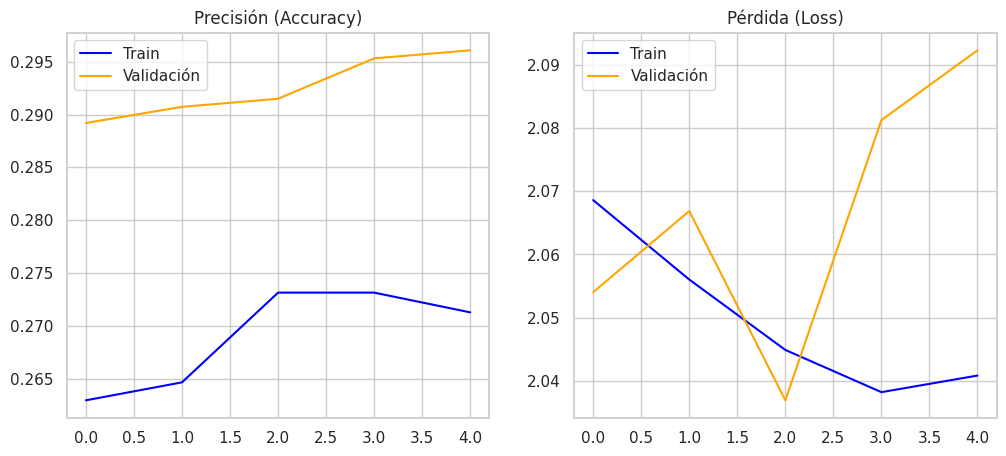

103/103 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step


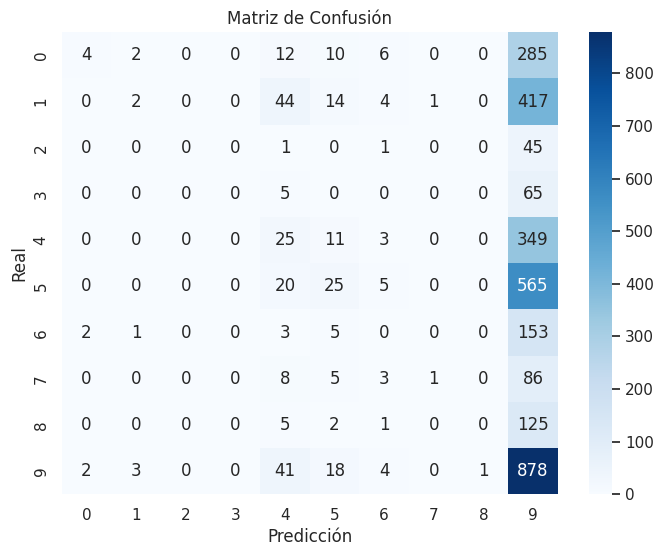

              precision    recall  f1-score   support

           0       0.50      0.01      0.02       319
           1       0.25      0.00      0.01       482
           2       0.00      0.00      0.00        47
           3       0.00      0.00      0.00        70
           4       0.15      0.06      0.09       388
           5       0.28      0.04      0.07       615
           6       0.00      0.00      0.00       164
           7       0.50      0.01      0.02       103
           8       0.00      0.00      0.00       133
           9       0.30      0.93      0.45       947

    accuracy                           0.29      3268
   macro avg       0.20      0.11      0.07      3268
weighted avg       0.26      0.29      0.16      3268

 pred[9 9 9 ... 0 4 9]
Hola [[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [63]:
matrizConfusion(modelo, X_test, y_test, history)

# Conclusiones